In [1]:
import sys
import os

project_root = os.path.dirname(os.path.dirname(os.getcwd()))
src_path = os.path.join(project_root, 'src')
sys.path.append(src_path)



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from algorithms.collaborative_filtering import UserBasedCF, ItemBasedCF
from algorithms.matrix_factorization import BasicMatrixFactorization, SVDMatrixFactorization
from algorithms.content_based import GenreBasedRecommender, DemographicBasedRecommender
from algorithms.hybrid import HybridRecommender
from algorithms.baselines import GlobalAverageRecommender, UserAverageRecommender, MovieAverageRecommender, BiasRecommender


ratings_df = pd.read_csv('../../data/ratings_processed.csv')  
movies_df = pd.read_csv('../../data/movies_processed.csv')  
users_df = pd.read_csv('../../data/users_processed.csv')


In [2]:
def draw_plots(rmse_values, mae_values, indexes, algorithm_name):
    figure = plt.figure(figsize=(20, 10))
    xlabel = (
        'k (neighbors)' if ('CF' in algorithm_name or algorithm_name == 'DemographicBasedRecommender')
        else 'Number of latent factors' if 'Factorization' in algorithm_name
        else 'Parameter'
    )
    ax1 = figure.add_subplot(1,2,1)
    ax1.plot(indexes, rmse_values, label=algorithm_name, color='red', marker='o')
    ax1.set_xlabel(xlabel); ax1.set_ylabel('RMSE'); ax1.legend()
    ax2 = figure.add_subplot(1,2,2)
    ax2.plot(indexes, mae_values, label=algorithm_name, color='blue', marker='o')
    ax2.set_xlabel(xlabel); ax2.set_ylabel('MAE'); ax2.legend()
    plt.show()

In [3]:

def tune_baselines_models(algorithm_name : str,train_df : pd.DataFrame ,test_dict : dict,actual_values : list):
    if algorithm_name == 'GlobalAverageRecommender':
        model = GlobalAverageRecommender() 
    elif algorithm_name == 'UserAverageRecommender':
        model = UserAverageRecommender()
    elif algorithm_name == 'MovieAverageRecommender':
        model = MovieAverageRecommender()
    elif algorithm_name == 'BiasRecommender':
        model = BiasRecommender()
    else:
        raise ValueError(f"Algorithm {algorithm_name} not found")
    model.fit(train_df)
    predictions = []
    for user, items in test_dict.items():
        for item in items:
            predictions.append(model.predict(user, item))
    predictions = np.array(predictions)
    actual_values = np.array(actual_values)
    rmse = np.sqrt(np.mean((predictions - actual_values)**2))
    mae = np.mean(np.abs(predictions - actual_values))
    print(f"RMSE for {algorithm_name}: {round(rmse,2)}")
    print(f"MAE for {algorithm_name}: {round(mae,2)}")

In [4]:
def tune_collaborative_filtering_models(algorithm_name : str,train_df : pd.DataFrame ,test_dict : dict,actual_values : list):
    k_values = [10,20,30,40,50]
    rmse_values = []
    mae_values = []
    best_rmse = float('inf')
    best_mae = float('inf')
    best_params = None
    for k in k_values:
        if algorithm_name == 'UserBasedCF':
            model = UserBasedCF()
        elif algorithm_name == 'ItemBasedCF':
            model = ItemBasedCF()
        else:
            raise ValueError(f"Algorithm {algorithm_name} not found")
        model.k = k
        model.fit(train_df)
        predictions = []
        for user, items in test_dict.items():
            for item in items:
                predictions.append(model.predict(user, item))
        predictions = np.array(predictions)
        actual_values = np.array(actual_values)
        rmse = np.sqrt(np.mean((predictions - actual_values)**2))
        mae = np.mean(np.abs(predictions - actual_values))
        if rmse < best_rmse:
            best_rmse = rmse
            best_params = k
        if mae < best_mae:
            best_mae = mae
          
        rmse_values.append(rmse)
        mae_values.append(mae)
    print(f"RMSE for {algorithm_name}: {round(best_rmse,2)}")
    print(f"MAE for {algorithm_name}: {round(best_mae,2)}")
    print(f"Best RMSE parameters for {algorithm_name}: {best_params}")
    draw_plots(rmse_values, mae_values, k_values,algorithm_name)


In [5]:
def tune_content_based_models(algorithm_name : str,train_df : pd.DataFrame ,test_dict : dict,actual_values : list):
    best_rmse = float('inf')
    best_mae = float('inf')
    best_params = None
    if algorithm_name == 'GenreBasedRecommender':
        model = GenreBasedRecommender()
        model.fit(train_df,movies_df)
        predictions = []
        for user, items in test_dict.items():
            for item in items:
                predictions.append(model.predict(user, item))
        predictions = np.array(predictions)
        actual_values = np.array(actual_values)
        best_rmse = np.sqrt(np.mean((predictions - actual_values)**2))
        best_mae = np.mean(np.abs(predictions - actual_values))

    elif algorithm_name == 'DemographicBasedRecommender':
        model = DemographicBasedRecommender()
        k_values = [10,20,30,40,50]
        rmse_values = []
        mae_values = []
        for k in k_values:
            model.k = k
            model.fit(train_df,users_df)
            predictions = []
            for user, items in test_dict.items():
                for item in items:
                    predictions.append(model.predict(user, item))
            predictions = np.array(predictions)
            actual_values = np.array(actual_values)
            rmse = np.sqrt(np.mean((predictions - actual_values)**2))
            mae = np.mean(np.abs(predictions - actual_values))
            if rmse < best_rmse:
                best_rmse = rmse
                best_params = k
            if mae < best_mae:
                best_mae = mae
            rmse_values.append(rmse)
            mae_values.append(mae)
    else:
        raise ValueError(f"Algorithm {algorithm_name} not found")
    print(f"RMSE for {algorithm_name}: {round(best_rmse,2)}")
    print(f"MAE for {algorithm_name}: {round(best_mae,2)}")
    if algorithm_name == 'DemographicBasedRecommender':
        print(f"Best RMSE parameters for {algorithm_name}: {best_params}")
        draw_plots(rmse_values, mae_values, k_values,algorithm_name)

In [6]:
from sklearn.model_selection import ParameterGrid
def tune_matrix_factorization_models(algorithm_name : str,train_df : pd.DataFrame ,test_dict : dict,actual_values : list):
    best_rmse = float('inf')
    best_mae = float('inf')
    best_params = None
    rmse_values = []
    mae_values = []
    if algorithm_name == 'SVDMatrixFactorization':
        model = SVDMatrixFactorization()
        model.fit(train_df)
        predictions = []
        for user, items in test_dict.items():
            for item in items:
                predictions.append(model.predict(user, item))
        predictions = np.array(predictions)
        actual_values = np.array(actual_values)
        best_rmse = np.sqrt(np.mean((predictions - actual_values)**2))
        best_mae = np.mean(np.abs(predictions - actual_values))
    elif algorithm_name == 'BasicMatrixFactorization':
        model = BasicMatrixFactorization()
        param_grid = {
        'k': [20, 40, 60],
        'epochs': [50, 100, 150],
        'learning_rate': [0.0005, 0.001, 0.002],
        'reg': [0.02, 0.05, 0.1]
        }
        parametrs = ParameterGrid(param_grid)
        for params in parametrs:
            model.k = params['k']
            model.epochs = params['epochs']
            model.learning_rate = params['learning_rate']
            model.reg = params['reg']
            model.fit(train_df)
            predictions = []
            for user, items in test_dict.items():
                for item in items:
                    predictions.append(model.predict(user, item))
            predictions = np.array(predictions)
            actual_values = np.array(actual_values)
            rmse = np.sqrt(np.mean((predictions - actual_values)**2))
            mae = np.mean(np.abs(predictions - actual_values))
            if rmse < best_rmse:
                best_rmse = rmse
                best_params = params
            if mae < best_mae:
                best_mae = mae
            rmse_values.append(rmse)
            mae_values.append(mae)
    else:
        raise ValueError(f"Algorithm {algorithm_name} not found")
    print(f"RMSE for {algorithm_name}: {round(best_rmse,2)}")
    print(f"MAE for {algorithm_name}: {round(best_mae,2)}")
    if algorithm_name == 'BasicMatrixFactorization':
        print(f"Best RMSE parameters for {algorithm_name}: {best_params}")
        draw_plots(rmse_values, mae_values, range(len(parametrs)),algorithm_name)

        

In [7]:
def prepare_data_for_tuning(missing_percentage: int,ratings_df: pd.DataFrame):
    test_size = missing_percentage / 100
    test_df = ratings_df.sample(frac=test_size, random_state=42)
    train_df = ratings_df.drop(test_df.index)
    
    users_to_predict = {}
    actual_ratings = []
    
    for _, row in test_df.iterrows():
        user = row['userId']
        movie = row['movieId']
        rating = row['rating']
        
        if user not in users_to_predict:
            users_to_predict[user] = []
        users_to_predict[user].append(movie)
        actual_ratings.append(rating)
    
    return users_to_predict, actual_ratings, train_df

In [8]:
rng = np.random.default_rng(42)
random_users = rng.integers(ratings_df['userId'].min(), ratings_df['userId'].max() + 1, size=500)
random_sample = ratings_df[ratings_df['userId'].isin(random_users)]
test_dict,actual_values,train_df = prepare_data_for_tuning(20,random_sample)

RMSE for UserBasedCF: 1.33
MAE for UserBasedCF: 1.07
Best RMSE parameters for UserBasedCF: 50


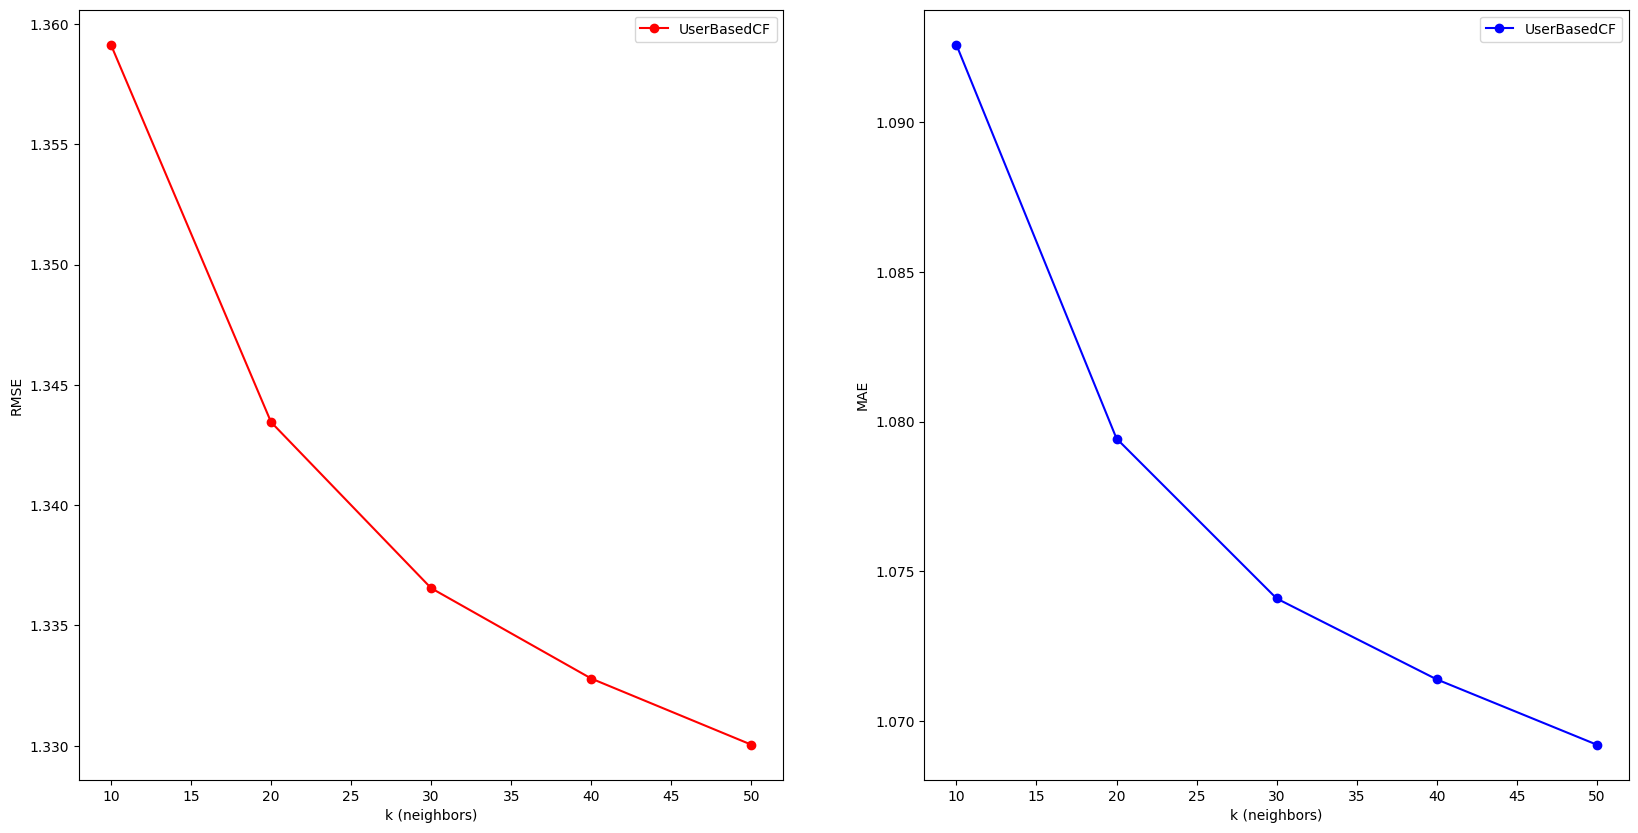

In [24]:
tune_collaborative_filtering_models('UserBasedCF',train_df,test_dict,actual_values)  

RMSE for ItemBasedCF: 1.38
MAE for ItemBasedCF: 1.1
Best RMSE parameters for ItemBasedCF: 50


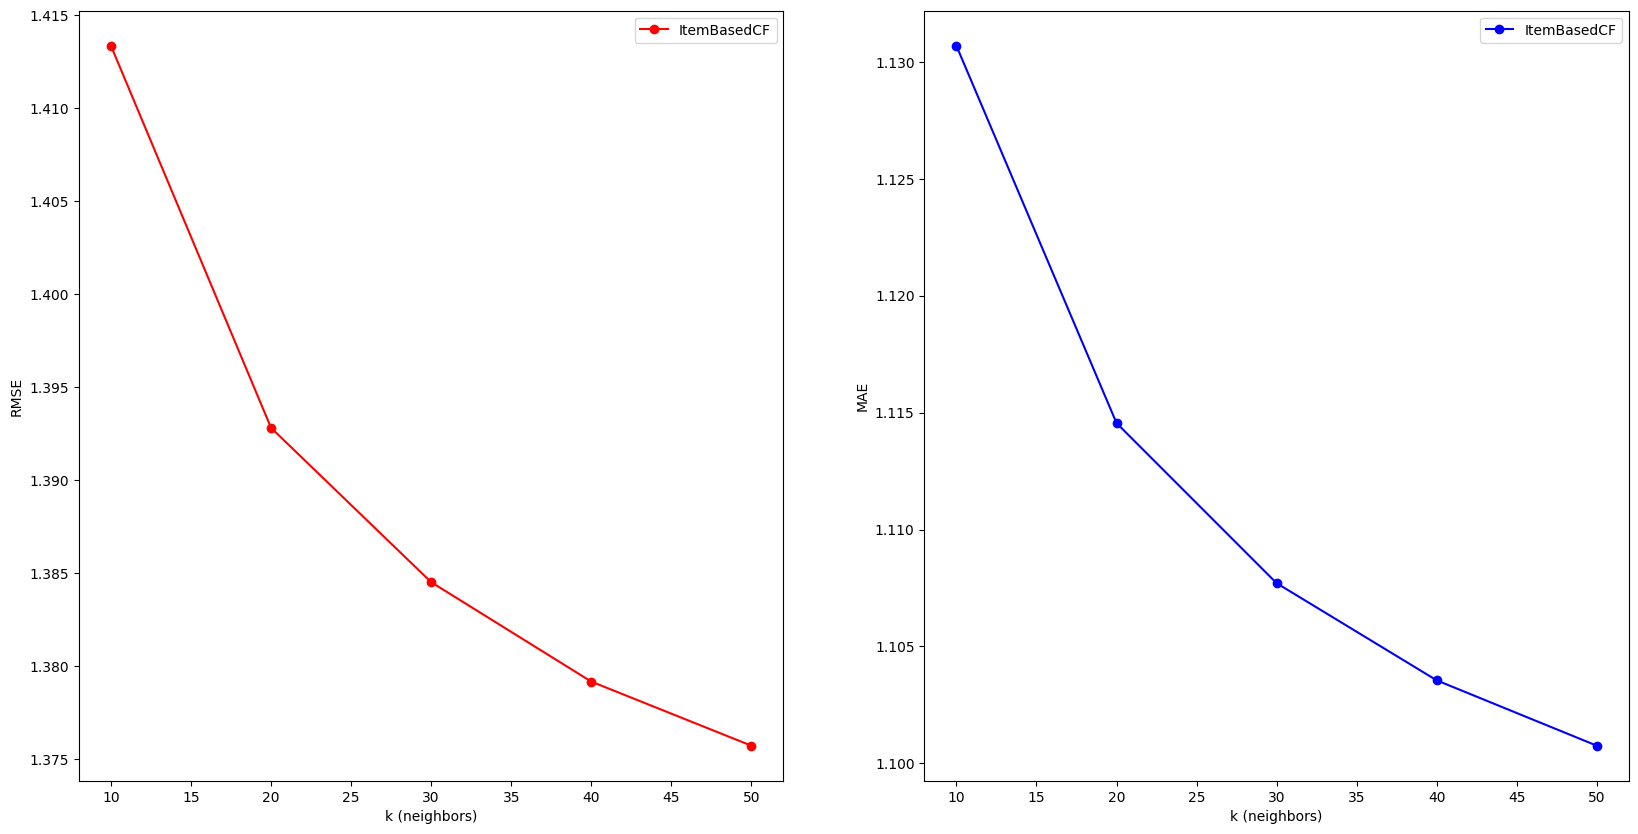

In [9]:
tune_collaborative_filtering_models('ItemBasedCF',train_df,test_dict,actual_values)

In [26]:
tune_content_based_models('GenreBasedRecommender',train_df,test_dict,actual_values)


RMSE for GenreBasedRecommender: 1.22
MAE for GenreBasedRecommender: 0.98


RMSE for DemographicBasedRecommender: 1.33
MAE for DemographicBasedRecommender: 1.07
Best RMSE parameters for DemographicBasedRecommender: 50


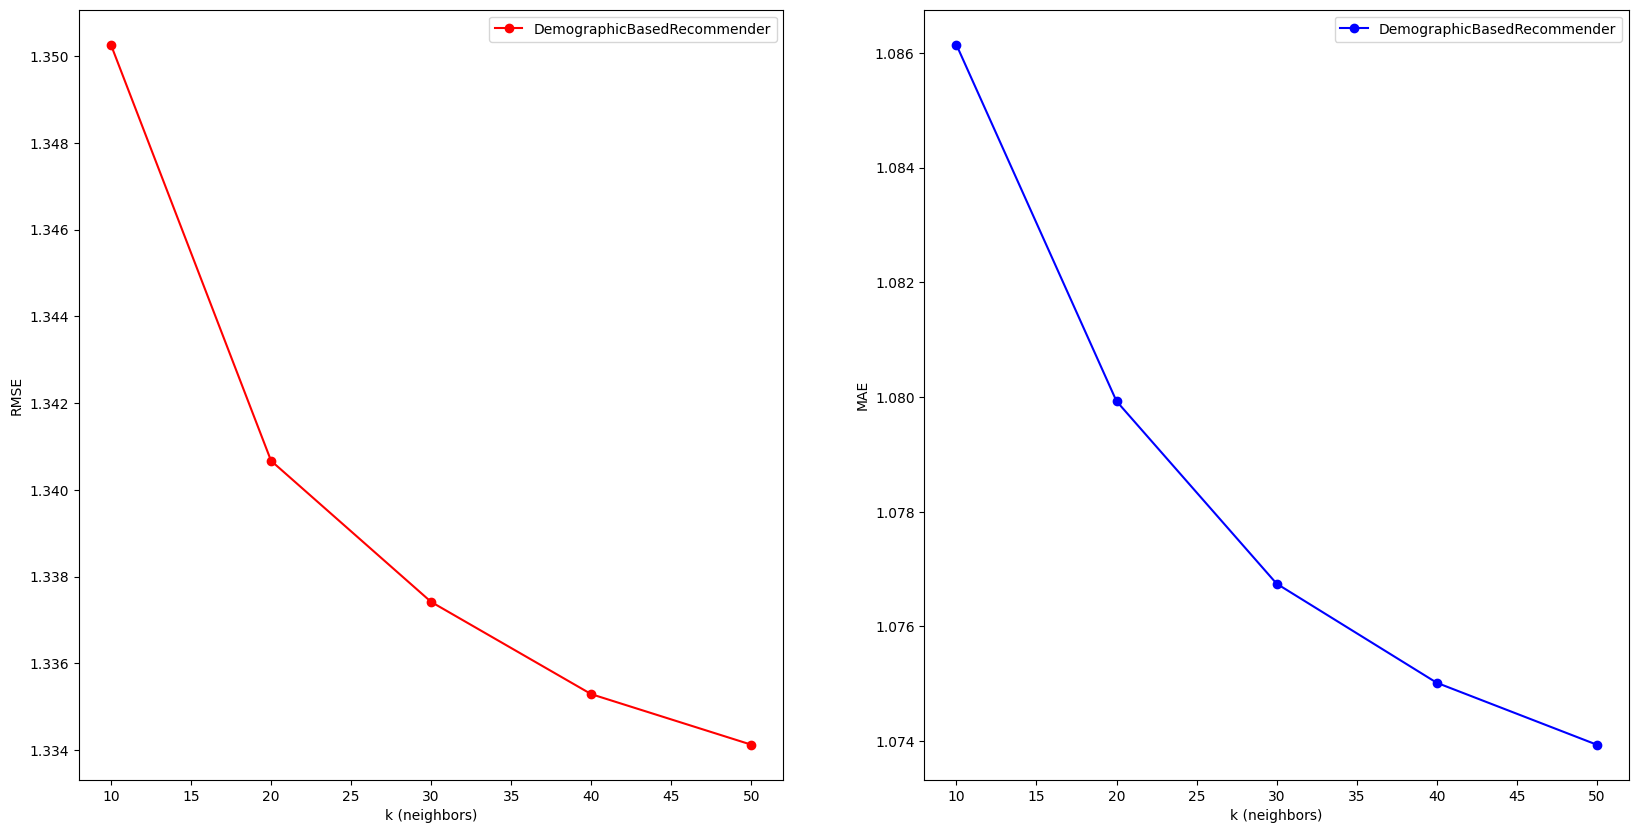

In [27]:
tune_content_based_models('DemographicBasedRecommender',train_df,test_dict,actual_values)

RMSE for BasicMatrixFactorization: 1.12
MAE for BasicMatrixFactorization: 0.94
Best RMSE parameters for BasicMatrixFactorization: {'epochs': 100, 'k': 60, 'learning_rate': 0.0005, 'reg': 0.1}


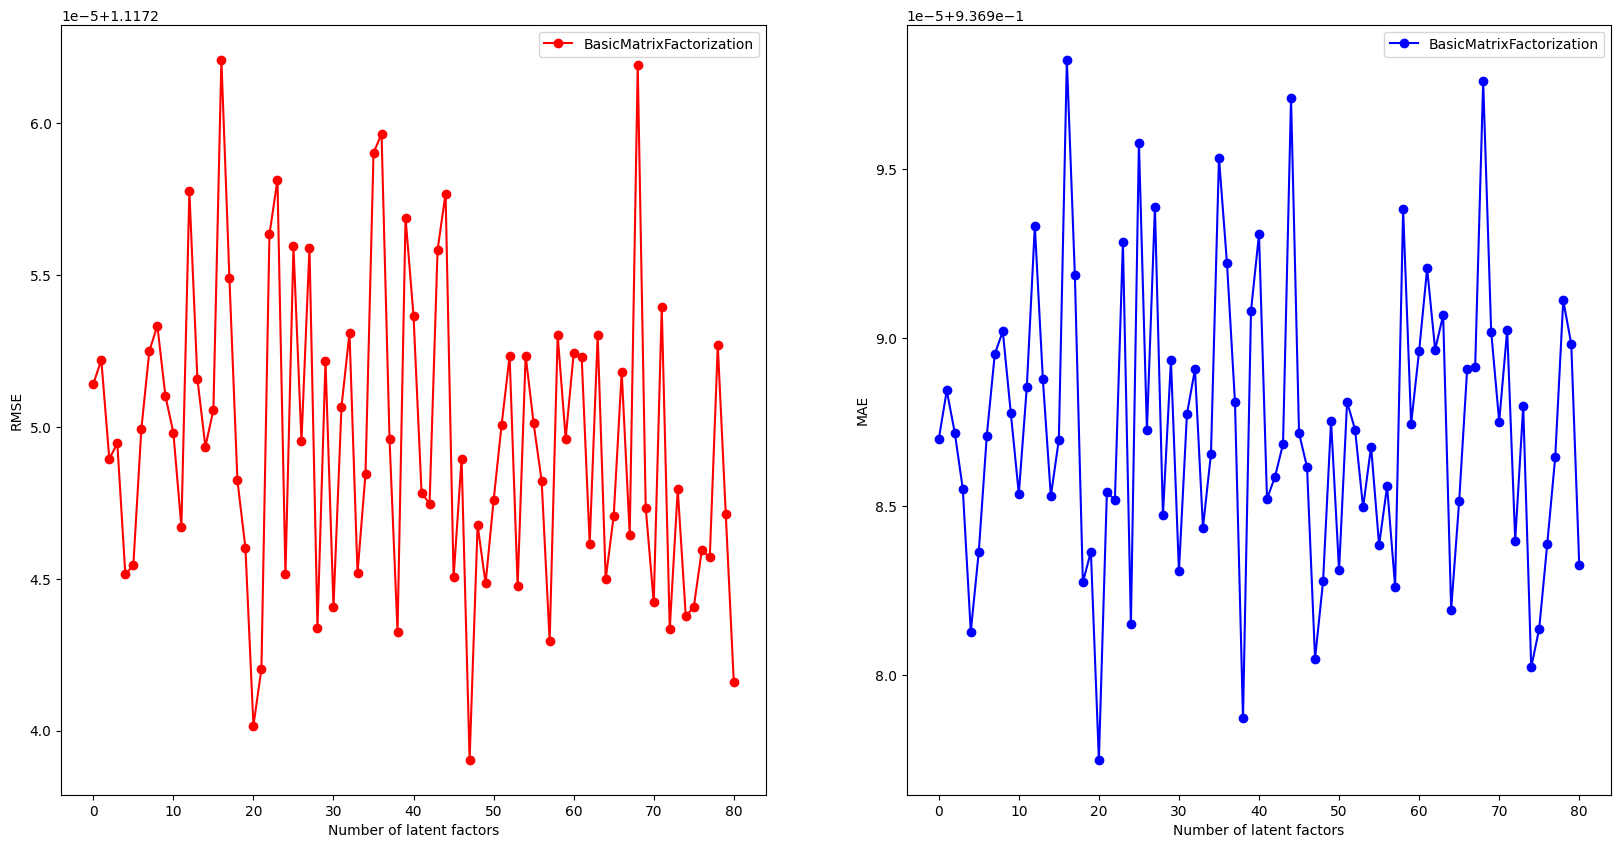

In [9]:
tune_matrix_factorization_models('BasicMatrixFactorization',train_df,test_dict,actual_values)

In [11]:
tune_matrix_factorization_models('SVDMatrixFactorization',train_df,test_dict,actual_values)

RMSE for SVDMatrixFactorization: 1.48
MAE for SVDMatrixFactorization: 1.15


In [13]:
from itertools import combinations

def tune_hybrid_models(train_df: pd.DataFrame, test_dict: dict, actual_values: list):
    """
    Fast hybrid tuning using cached predictions (uniform weights).

    Models:
      1 - UserBasedCF
      2 - ItemBasedCF
      3 - GenreBasedRecommender
      4 - DemographicBasedRecommender
      5 - BasicMatrixFactorization
      6 - SVDMatrixFactorization
    """

    pairs = [(u, i) for u, items in test_dict.items() for i in items]
    y = np.array(actual_values, dtype=float)

    models = {
        'UserBasedCF': UserBasedCF(k=50),
        'ItemBasedCF': ItemBasedCF(k=50),
        'GenreBasedRecommender': GenreBasedRecommender(),
        'DemographicBasedRecommender': DemographicBasedRecommender(k=50),
        'BasicMatrixFactorization': BasicMatrixFactorization(k=60, epochs=100, learning_rate=0.0005, reg=0.1),
        'SVDMatrixFactorization': SVDMatrixFactorization(k=60),
    }
    models['UserBasedCF'].fit(train_df)
    models['ItemBasedCF'].fit(train_df)
    models['GenreBasedRecommender'].fit(train_df, movies_df)
    models['DemographicBasedRecommender'].fit(train_df, users_df)
    models['BasicMatrixFactorization'].fit(train_df)
    models['SVDMatrixFactorization'].fit(train_df)

    model_names = list(models.keys())
    preds_cols = []
    for name in model_names:
        m = models[name]
        preds_cols.append(np.array([m.predict(u, i) for (u, i) in pairs], dtype=float))
    P = np.column_stack(preds_cols) 

    best_rmse = float('inf')
    best_mae = float('inf')
    best_subset = None
    rmse_values, mae_values = [], []

    indices = list(range(len(model_names)))
    subsets = []
    for r in range(2, len(model_names) + 1):
        subsets.extend(combinations(indices, r))

    for subset in subsets:
        y_hat = P[:, subset].mean(axis=1)
        rmse = float(np.sqrt(np.mean((y_hat - y) ** 2)))
        mae = float(np.mean(np.abs(y_hat - y)))
        rmse_values.append(rmse)
        mae_values.append(mae)
        if rmse < best_rmse:
            best_rmse = rmse
            best_subset = subset
        if mae < best_mae:
            best_mae = mae

    best_models = tuple(model_names[i] for i in best_subset) if best_subset is not None else ()

    print(f"Best RMSE: {round(best_rmse,2)}")
    print(f"Best MAE: {round(best_mae,2)}")
    print(f"Best Parameters: {best_models}")

    draw_plots(rmse_values, mae_values, range(len(subsets)), 'HybridSystem')


Best RMSE: 1.14
Best MAE: 0.93
Best Parameters: ('GenreBasedRecommender', 'BasicMatrixFactorization')


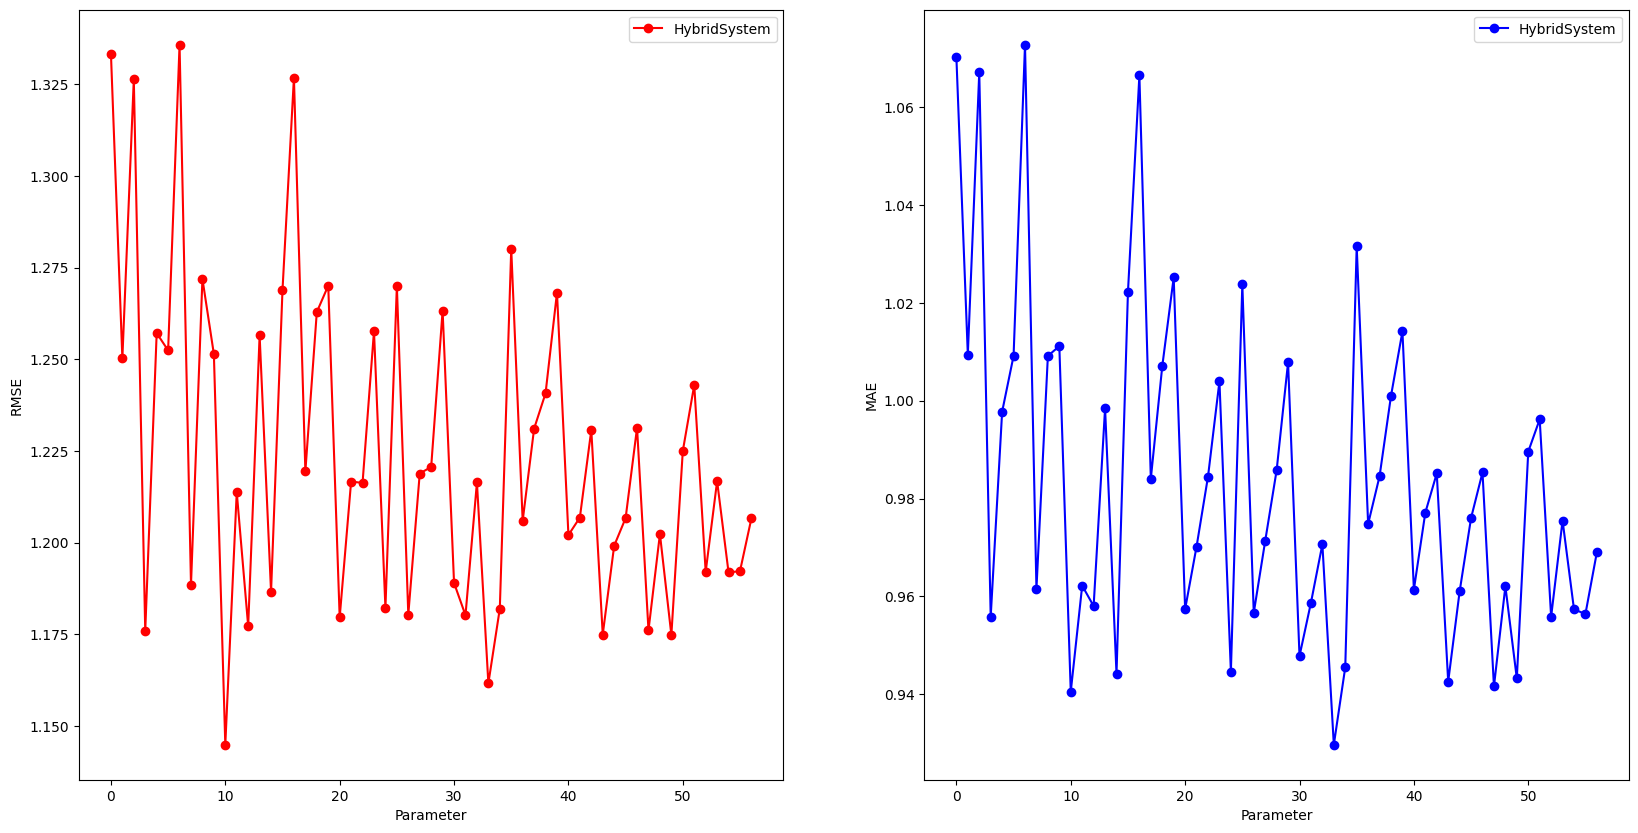

In [14]:
tune_hybrid_models(train_df,test_dict,actual_values)

In [17]:
import json
from pathlib import Path

def save_params_json(path, params: dict):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(params, f, indent=2, ensure_ascii=False)


best_params = {
    "UserBasedCF": {"k": 50},
    "ItemBasedCF": {"k": 50},
    "GenreBasedRecommender": {},
    "DemographicBasedRecommender": {"k": 50},
    "BasicMatrixFactorization": {"k": 60, "epochs": 100, "learning_rate": 0.0005, "reg": 0.1},
    "SVDMatrixFactorization": {"k": 60},
    "Hybrid": {
        "models": ["GenreBasedRecommender", "BasicMatrixFactorization"],  
        "weights": [0.5, 0.5]
    }
}

for name, params in best_params.items():
    save_params_json(f"../../models/{name}.json", params)